<a href="https://colab.research.google.com/github/alisha-q/fraud-detection-shap/blob/main/notebooks/03_baseline_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')
project_path = "/content/drive/MyDrive/credit-card-fraud-detection-project"

Mounted at /content/drive


# Explainable Credit Card Fraud Detection - Baseline: Logistic Regression

**Module:** 2 - Model Building and Comparison (Model 1 of 3)

**Goal:** Train Logistic Regression as the interpretable baseline model, establishing the
minimum acceptable performance bar before moving to ensemble methods (Interim Report,
Section 4.3).

In [2]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report,
                              precision_recall_curve, average_precision_score)

sns.set_style("whitegrid")

with open(f"{project_path}/models/preprocessed_splits.pkl", "rb") as f:
    splits = pickle.load(f)

X_train_resampled = splits["X_train_resampled"]; y_train_resampled = splits["y_train_resampled"]
X_val, y_val = splits["X_val"], splits["y_val"]
X_test, y_test = splits["X_test"], splits["y_test"]

print(f"Training on {len(X_train_resampled):,} rows (post-SMOTE), "
      f"testing on {len(X_test):,} untouched real-world-ratio rows")

Training on 298,530 rows (post-SMOTE), testing on 42,722 untouched real-world-ratio rows


---
## 1) Train Logistic Regression

`class_weight='balanced'` is layered on top of the SMOTE-resampled training data as an
extra safeguard against the residual imbalance, and `max_iter` is raised because
high-dimensional, class-weighted logistic regression can need more iterations to converge.

In [3]:
logreg = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    C=1.0,
    solver="lbfgs",
    random_state=42,
)
logreg.fit(X_train_resampled, y_train_resampled)
print("Logistic Regression trained.")

Logistic Regression trained.


---
## 2) Evaluate on the Untouched Test Set

In [4]:
proba_test = logreg.predict_proba(X_test)[:, 1]

# --- Threshold 1: F1-optimal (balanced operating point) ---
thresholds = np.linspace(0.01, 0.99, 197)
best_f1, best_thr = -1, 0.5
for thr in thresholds:
    pred = (proba_test >= thr).astype(int)
    f1 = f1_score(y_test, pred, zero_division=0)
    if f1 > best_f1:
        best_f1, best_thr = f1, thr

pred_f1opt = (proba_test >= best_thr).astype(int)
print(f"F1-optimal threshold = {best_thr:.2f}")
print(f"Accuracy : {accuracy_score(y_test, pred_f1opt):.4f}")
print(f"Precision: {precision_score(y_test, pred_f1opt):.4f}")
print(f"Recall   : {recall_score(y_test, pred_f1opt):.4f}")
print(f"F1-Score : {f1_score(y_test, pred_f1opt):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, proba_test):.4f}")

F1-optimal threshold = 0.99
Accuracy : 0.9984
Precision: 0.5299
Recall   : 0.8378
F1-Score : 0.6492
ROC-AUC  : 0.9613


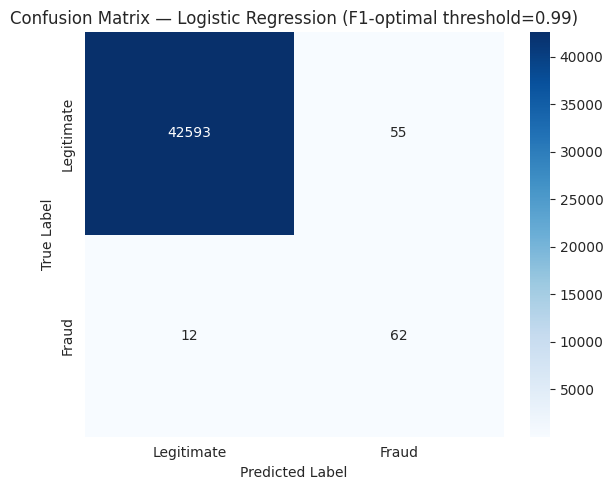

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     42648
       Fraud       0.53      0.84      0.65        74

    accuracy                           1.00     42722
   macro avg       0.76      0.92      0.82     42722
weighted avg       1.00      1.00      1.00     42722



In [5]:
cm = confusion_matrix(y_test, pred_f1opt)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legitimate','Fraud'], yticklabels=['Legitimate','Fraud'])
plt.title(f'Confusion Matrix — Logistic Regression (F1-optimal threshold={best_thr:.2f})')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(f"{project_path}/results/confusion_matrix_logistic_regression.png", dpi=300)
plt.show()

print(classification_report(y_test, pred_f1opt, target_names=["Legitimate", "Fraud"]))

### Recall-priority operating point

Because a missed fraud case (false negative) is far more costly than a false alarm (Interim
Report, Section 4.3), we also report a "screening mode" threshold constrained to recall
&ge; 0.90 — useful if this model were deployed as a first-pass filter ahead of manual review.

In [6]:
best_f1_screen, best_thr_screen = -1, 0.5
for thr in thresholds:
    pred = (proba_test >= thr).astype(int)
    rec = recall_score(y_test, pred, zero_division=0)
    if rec >= 0.90:
        f1 = f1_score(y_test, pred, zero_division=0)
        if f1 > best_f1_screen:
            best_f1_screen, best_thr_screen = f1, thr

pred_screen = (proba_test >= best_thr_screen).astype(int)
print(f"Recall-screening threshold = {best_thr_screen:.2f}")
print(f"Precision: {precision_score(y_test, pred_screen):.4f}  "
      f"Recall: {recall_score(y_test, pred_screen):.4f}  "
      f"F1: {f1_score(y_test, pred_screen):.4f}")

Recall-screening threshold = 0.15
Precision: 0.0127  Recall: 0.9054  F1: 0.0250


---
## 2b) Precision-Recall Curve & AUPRC

The dataset card on Kaggle notes that, given the severe class imbalance (0.172%
fraud), **AUPRC (Area Under the Precision-Recall Curve)** is the recommended accuracy
measure rather than plain accuracy or even ROC-AUC, since ROC-AUC can look
misleadingly high once the negative class dominates this heavily. We report AUPRC
here as a threshold-independent summary alongside ROC-AUC.


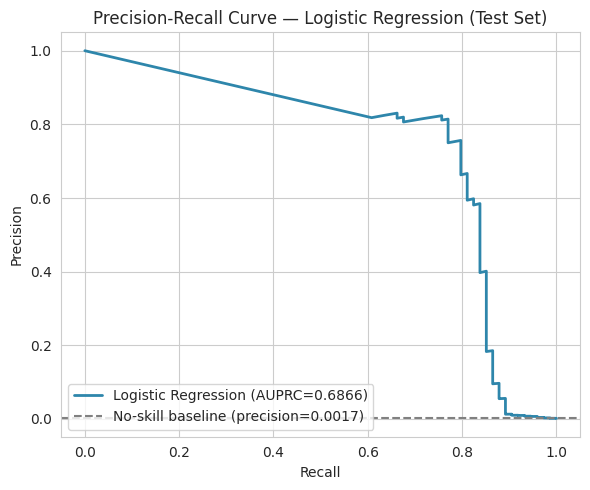

AUPRC: 0.6866


In [7]:
precision_curve, recall_curve, _ = precision_recall_curve(y_test, proba_test)
auprc_logreg = average_precision_score(y_test, proba_test)

baseline_rate = y_test.mean()  # precision of a random/no-skill classifier

plt.figure(figsize=(6, 5))
plt.plot(recall_curve, precision_curve, color="#2E86AB", linewidth=2,
         label=f"Logistic Regression (AUPRC={auprc_logreg:.4f})")
plt.axhline(baseline_rate, linestyle="--", color="gray",
            label=f"No-skill baseline (precision={baseline_rate:.4f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Logistic Regression (Test Set)")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig(f"{project_path}/results/pr_curve_logistic_regression.png", dpi=300)
plt.show()

print(f"AUPRC: {auprc_logreg:.4f}")


---
## 3) Save Model

In [8]:
with open(f"{project_path}/models/logistic_regression.pkl", "wb") as f:
    pickle.dump(logreg, f)

results_logreg = {
    "model": "Logistic Regression",
    "f1_optimal_threshold": float(best_thr),
    "accuracy": float(accuracy_score(y_test, pred_f1opt)),
    "precision": float(precision_score(y_test, pred_f1opt)),
    "recall": float(recall_score(y_test, pred_f1opt)),
    "f1": float(f1_score(y_test, pred_f1opt)),
    "roc_auc": float(roc_auc_score(y_test, proba_test)),
    "auprc": float(auprc_logreg),
}
print(results_logreg)

{'model': 'Logistic Regression', 'f1_optimal_threshold': 0.99, 'accuracy': 0.9984317213613595, 'precision': 0.5299145299145299, 'recall': 0.8378378378378378, 'f1': 0.6492146596858639, 'roc_auc': 0.9612814136590164, 'auprc': 0.6866441076792491}


---
## Summary

- Trained a `class_weight='balanced'` Logistic Regression on the SMOTE-resampled training
  set.
- Reported both an F1-optimal (balanced) and a recall-priority (screening) operating point,
  since the two serve different business purposes.
- This baseline establishes the bar that Random Forest and XGBoost need to clear in the next
  notebook.

**Next:** `04_random_forest_xgboost.ipynb` — ensemble models and full 3-way comparison.